# ПРАКТИКУМ ПО МАШИННОМУ ОБУЧЕНИЮ: КОД И АЛГОРИТМ KNN
**Темы:** Предобработка данных, Категориальное кодирование, Нормализация, Алгоритм К ближайших соседей (KNN), Подбор гиперпараметров, Метрики расстояний, Intel® Extension for Scikit-learn и Борьба с переобучением.

### Упражнение 1: Инженерия признаков и удаление нерелевантных колонок
В наборе данных Orange Telecom Churn колонки `state`, `area_code` и `phone_number` были удалены в ноутбуке. Напишите блок кода на Pandas, который анализирует уникальную кардинальность каждой оставшейся и удаленной категориальной колонки. Объясните с математической точки зрения, почему применение `OneHotEncoder` или `LabelBinarizer` к колонке со сотнями уникальных значений (например, `phone_number`) разрушит пространственную эффективность и вызовет высокий риск переобучения для алгоритма KNN.

In [1]:
# Напишите ваш код здесь
import pandas as pd

# Пример загрузки или анализа данных
# df = pd.read_csv('telecom_churn.csv')
# print(df.nunique())

import os

data_path = ['..', '..', '..', 'datasets']
filepath = os.sep.join(data_path + ['Orange_Telecom_Churn_Data.csv'])
data = pd.read_csv(filepath)
data.head(5).T

,0,1,2,3,4
state,KS,OH,NJ,OH,OK
account_length,128,107,137,84,75
area_code,415,415,415,408,415
phone_number,382-4657,371-7191,358-1921,375-9999,330-6626
intl_plan,no,no,no,yes,yes
voice_mail_plan,yes,yes,no,no,no
number_vmail_messages,25,26,0,0,0
total_day_minutes,265.1,161.6,243.4,299.4,166.7
total_day_calls,110,123,114,71,113
total_day_charge,45.07,27.47,41.38,50.9,28.34


In [2]:
# сколько разных значений во всех колонках
print(data.nunique())

state                              51
account_length                    218
area_code                           3
phone_number                     5000
intl_plan                           2
voice_mail_plan                     2
number_vmail_messages              48
total_day_minutes                1961
total_day_calls                   123
total_day_charge                 1961
total_eve_minutes                1879
total_eve_calls                   126
total_eve_charge                 1659
total_night_minutes              1853
total_night_calls                 131
total_night_charge               1028
total_intl_minutes                170
total_intl_calls                   21
total_intl_charge                 170
number_customer_service_calls      10
churned                             2
dtype: int64


In [3]:
# сколько разных значений в категориальных колонках
# area_code записан числом, но это код региона, поэтому его тоже считаем категориальным
cat_cols = ['state', 'area_code', 'phone_number', 'intl_plan', 'voice_mail_plan']
data[cat_cols].nunique()

state                51
area_code             3
phone_number       5000
intl_plan             2
voice_mail_plan       2
dtype: int64

In [4]:
# у area_code всего 3 значения, посмотрим, отличается ли между ними отток
data.groupby('area_code')['churned'].mean()

area_code
408    0.140588
415    0.138677
510    0.147673
Name: churned, dtype: float64

In [5]:
# дальше как в ноутбуке урока: удаляем эти колонки и переводим yes/no и True/False в 0/1
from sklearn.preprocessing import LabelBinarizer

data.drop(['state', 'area_code', 'phone_number'], axis=1, inplace=True)

lb = LabelBinarizer()
for col in ['intl_plan', 'voice_mail_plan', 'churned']:
    data[col] = lb.fit_transform(data[col])

x_cols = [x for x in data.columns if x != 'churned']
X_data = data[x_cols]
y_data = data['churned']

В `phone_number` 5000 разных значений на 5000 строк, то есть это просто идентификатор клиента. OneHotEncoder или LabelBinarizer сделает из него 5000 колонок почти из одних нулей, и вместо 17 признаков их станет больше 5000. Расстояния тогда считаются по 5000 измерениям, поэтому растут и память, и время.

У двух разных клиентов такие one-hot векторы отличаются ровно в двух местах, значит к квадрату расстояния между любыми двумя клиентами добавляется одно и то же число: $d^2 = d^2_{\text{остальные признаки}} + 2$. Информации в этом нет, а настоящие различия между клиентами становятся менее заметны. Кроме того, номер нового клиента модель никогда не видела, поэтому по этим колонкам она может только запомнить обучающие данные, а это и есть переобучение.

Со `state` (51 значение) та же проблема, только слабее. `area_code` на отток почти не влияет: доля ушедших во всех трех кодах от 0.139 до 0.148.

### Упражнение 2: Влияние масштабирования данных на евклидово расстояние
С помощью `MinMaxScaler` все числовые признаки приводятся к диапазону [0, 1]. Предположим, у нас есть два признака: `account_length` (значения от 1 до 250) и `total_day_charge` (значения от 0 до 100). Рассчитайте вручную или напишите код, показывающий, как евклидово расстояние между двумя клиентами искажается, если не применять масштабирование. Что произойдет, если использовать `StandardScaler` вместо `MinMaxScaler`, когда в распределении данных присутствуют выбросы (outliers)?

In [6]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# Напишите ваш код для сравнения скейлеров здесь

import numpy as np

# два клиента: [account_length, total_day_charge]
client1 = np.array([74, 18.5])
client2 = np.array([131, 41.2])

diff = client2 - client1
print('разница по признакам:', diff)
print('расстояние:', np.linalg.norm(diff).round(2))
print('доля account_length в квадрате расстояния:', (diff[0] ** 2 / np.sum(diff ** 2)).round(2))

разница по признакам: [57.  22.7]
расстояние: 61.35
доля account_length в квадрате расстояния: 0.86


In [7]:
# теперь MinMax вручную, (x - min) / (max - min), диапазоны из условия
mins = np.array([1, 0])
maxs = np.array([250, 100])

diff_s = (client2 - mins) / (maxs - mins) - (client1 - mins) / (maxs - mins)
print('разница после MinMax:', diff_s.round(3))
print('расстояние:', np.linalg.norm(diff_s).round(3))
print('доля account_length в квадрате расстояния:', (diff_s[0] ** 2 / np.sum(diff_s ** 2)).round(2))

разница после MinMax: [0.229 0.227]
расстояние: 0.322
доля account_length в квадрате расстояния: 0.5


In [8]:
# выбросы: берем настоящий total_day_charge и добавляем одно значение 380
# (такого не бывает, это больше суток разговоров, как будто ошибка при вводе)
charge = data[['total_day_charge']].values
charge_out = np.vstack([charge, [[380]]])

mm = MinMaxScaler().fit_transform(charge_out)
st_clean = StandardScaler().fit_transform(charge)
st = StandardScaler().fit_transform(charge_out)

print('MinMax с выбросом: обычные точки от', mm[:-1].min().round(2), 'до', mm[:-1].max().round(2), 'выброс', mm[-1, 0].round(2))
print('Standard без выброса: от', st_clean.min().round(2), 'до', st_clean.max().round(2))
print('Standard с выбросом: обычные точки от', st[:-1].min().round(2), 'до', st[:-1].max().round(2), 'выброс', st[-1, 0].round(2))

MinMax с выбросом: обычные точки от 0.0 до 0.16 выброс 1.0
Standard без выброса: от -3.35 до 3.18
Standard с выбросом: обычные точки от -2.95 до 2.79 выброс 33.56


Клиенты отличаются примерно на 23% шкалы и по `account_length`, и по `total_day_charge`, но без масштабирования 86% квадрата расстояния дает `account_length`, просто потому что у него больше числа. После MinMax вклад признаков почти одинаковый. Значит, без масштабирования KNN почти не замечает признаки с маленькими значениями.

С выбросом MinMax сжимает все обычные значения в отрезок от 0 до 0.16, потому что максимум теперь задает выброс. StandardScaler здесь ведет себя лучше: среднее и std считаются по всем 5000 значениям, один выброс меняет их мало, и обычные точки сжимаются совсем немного. Но сам выброс получает z около 34, то есть оказывается очень далеко от всех точек, и значения больше не ограничены отрезком [0, 1]. Если выбросов много, std тоже сильно растет и обычные точки сжимаются, так что полностью проблему StandardScaler не решает.

### Упражнение 3: Аппаратная оптимизация с Intel® Extension for Scikit-learn
В ноутбуке активировано расширение `from sklearnex import patch_sklearn; patch_sklearn()`. Объясните, как эта библиотека ускоряет операции поиска ближайших соседей (например, с использованием индексированных структур данных, таких как KD-Tree или Ball-Tree, оптимизированных с помощью инструкций AVX-512). Напишите фрагмент кода, измеряющий время выполнения (`timeit`) для обучения `KNeighborsClassifier` с патчем Intel и без него на синтетическом наборе из 100 000 объектов.

In [9]:
import time
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Создание синтетических данных
X = np.random.rand(100000, 10)
y = np.random.randint(0, 2, 100000)

# Измерение времени обучения без патча и с патчем

X_query = np.random.rand(1500, 10)  # точки, для которых делаем predict

# -n 1 -r 3 значит 3 замера по одному запуску
knn = KNeighborsClassifier(n_neighbors=5)
%timeit -n 1 -r 3 knn.fit(X, y)
%timeit -n 1 -r 3 knn.predict(X_query)

162 ms ± 45 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
256 ms ± 16 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [10]:
# теперь с патчем. patch_sklearn подменяет классы sklearn на версии Intel,
# поэтому KNeighborsClassifier надо заново импортировать после патча
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.neighbors import KNeighborsClassifier

knn_intel = KNeighborsClassifier(n_neighbors=5)
%timeit -n 1 -r 3 knn_intel.fit(X, y)
%timeit -n 1 -r 3 knn_intel.predict(X_query)

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


58.6 ms ± 3.36 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
28.9 ms ± 4.23 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [11]:
# выключаем патч обратно, потому что в версии Intel weights='distance' работает немного по-другому,
# и в упражнении 5 результат отличался бы от обычного sklearn
from sklearnex import unpatch_sklearn
unpatch_sklearn()
from sklearn.neighbors import KNeighborsClassifier

С патчем быстрее и fit, и особенно predict. fit у KNN только запоминает данные и строит дерево для поиска, а основная работа в predict, где для каждой точки ищутся k ближайших соседей. sklearnex заменяет эту часть на библиотеку Intel oneDAL: brute force там считает расстояния сразу для блоков точек через матричное умножение, есть свой оптимизированный KD-tree, используются все ядра процессора и векторные инструкции AVX2 и AVX-512, которые обрабатывают несколько чисел за одну операцию. На ноутбуке, где запускался этот код, есть только AVX2.

### Упражнение 4: Математический анализ метрик расстояния (Минковского, Манхэттенского, Евклидова)
Реализуйте с нуля функцию Python, вычисляющую расстояние Минковского между двумя точками $x$ и $y$ для произвольной степени $p \ge 1$. Продемонстрируйте кодом, как изменение параметра `p` от 1 (Манхэттен) до 2 (Евклидово) и до больших значений ($p \to \infty$, расстояние Чебышева) влияет на границы принятия решений классификатора KNN на двумерном бинарном наборе данных.

In [12]:
def minkowski_distance(x, y, p):
    return np.sum(np.abs(x - y) ** p) ** (1 / p)

# Протестируйте функцию и постройте границы принятия решений

a = np.array([1.5, -2.0])
b = np.array([4.0, 3.5])

for p in [1, 2, 3, 8, 30]:
    print(p, round(minkowski_distance(a, b, p), 4))

# при p, стремящемся к бесконечности, в пределе остается максимум разности, это расстояние Чебышева
print('inf', np.max(np.abs(a - b)))

# получаем 8 для Манхэттена, 6.04 для Евклида, а дальше расстояние уменьшается и стремится к 5.5,
# то есть к самой большой разнице по одной координате

1 8.0
2 6.0415
3 5.6671
8 5.5013
30 5.5
inf 5.5


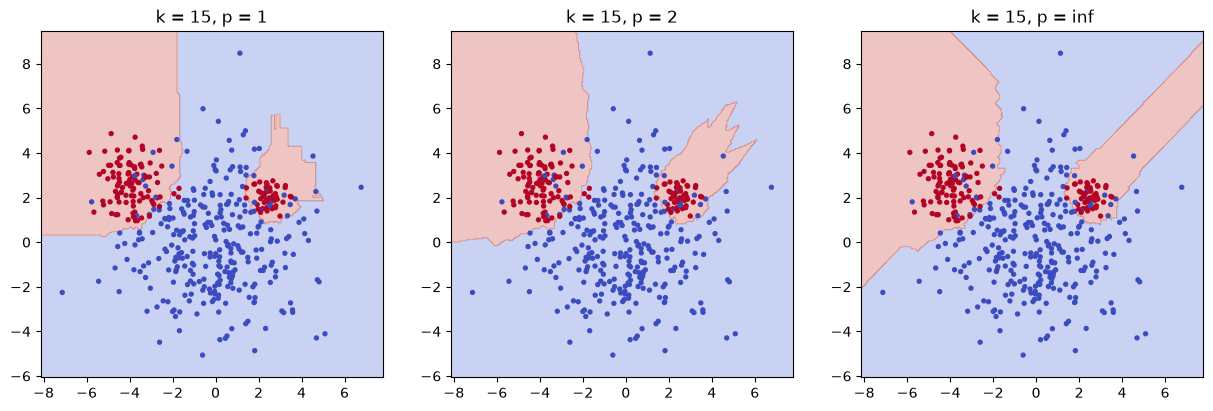

In [13]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

# три облака разного размера, которые пересекаются по краям:
# большое облако это класс 0, маленькое и среднее облака это класс 1
X2, blob = make_blobs(n_samples=[300, 50, 100], centers=[[0, 0], [2.5, 2], [-4, 2.5]],
                      cluster_std=[2.2, 0.4, 0.9], random_state=42)
y2 = (blob > 0).astype(int)

# сетка точек по всей плоскости, для каждой предсказываем класс и закрашиваем области
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, p in zip(axes, [1, 2, np.inf]):
    # встроенные метрики, потому что своя функция через metric= на сетке считалась бы очень долго
    if p == np.inf:
        knn = KNeighborsClassifier(n_neighbors=15, metric='chebyshev')
    else:
        knn = KNeighborsClassifier(n_neighbors=15, p=p)
    knn.fit(X2, y2)
    Z = knn.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap='coolwarm', s=8)
    ax.set_title('k = 15, p = ' + str(p))
plt.show()

# При p = 1 границы горизонтальные и вертикальные, при p = inf идут по диагонали, а при p = 2 что-то среднее, более плавное.
# Сильнее всего это видно у маленького облака справа: при p = 1 ему достается узкий столбик вверх,
# при p = 2 узкий клин, а при p = inf широкая полоса по диагонали до самого края.
# Причина в форме окрестности: при p = 1 это ромб, при p = 2 круг, при p = inf квадрат.

### Упражнение 5: Парадокс 100% точности при K=3 на обучающей выборке
Как отмечалось в вопросе 5 ноутбука, запуск KNN с параметром `weights='distance'` или $K=1$ на полном наборе данных (без разделения train/test) дает точность 1.0 (100%). Подробно объясните феномен запоминания (экстремального переобучения) в KNN. Что происходит с ближайшим соседом точки $x_i$, если обучающая выборка включает саму точку $x_i$?

In [14]:
# Эксперимент с K=1 на обучающей выборке

# сначала как в ноутбуке урока: нормируем все данные и проверяем на тех же данных, на которых обучали
X_scaled = MinMaxScaler().fit_transform(X_data)

# функция accuracy из урока, только там внутри по ошибке стояли y_data и y_pred вместо аргументов
def accuracy(real, predict):
    return sum(real == predict) / float(real.shape[0])

for k in [1, 3, 5]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_scaled, y_data)
    print('k =', k, 'uniform', accuracy(y_data, knn.predict(X_scaled)))
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance').fit(X_scaled, y_data)
    print('k =', k, 'distance', accuracy(y_data, knn.predict(X_scaled)))

k = 1 uniform 1.0
k = 1 distance 1.0
k = 3 uniform 0.9422
k = 3 distance 1.0
k = 5 uniform 0.9284
k = 5 distance 1.0


In [15]:
# кто ближайший сосед у первых пяти точек
knn = KNeighborsClassifier(n_neighbors=1).fit(X_scaled, y_data)
dist, idx = knn.kneighbors(X_scaled[:5])
print(dist.ravel())
print(idx.ravel())

[0.00000000e+00 4.21468485e-08 4.21468485e-08 0.00000000e+00
 0.00000000e+00]
[0 1 2 3 4]


In [16]:
# теперь проверим на данных, которых модель не видела
from sklearn.model_selection import train_test_split

# stratify, чтобы доля ушедших (около 14%) была одинаковой в train и test
# random_state, чтобы разбиение не менялось при перезапуске
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, stratify=y_data, random_state=42)

# scaler обучаем только на train, иначе информация из test попадет в обучение
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

for k in [1, 3, 5]:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance').fit(X_train_s, y_train)
    print('k =', k, 'train', round(knn.score(X_train_s, y_train), 4), 'test', round(knn.score(X_test_s, y_test), 4))

k = 1 train 1.0 test 0.8753
k = 3 train 1.0 test 0.8987
k = 5 train 1.0 test 0.8987


Если точка $x_i$ есть в обучающей выборке, ее ближайший сосед это она сама на расстоянии 0 (выше индексы соседей совпадают с номерами точек, а 4e-08 это ошибка округления). При K = 1 модель просто возвращает метку самой точки, поэтому на train всегда 100%. При `weights='distance'` вес соседа равен 1/d, при d = 0 он бесконечный, и sklearn отдает весь голос этой точке, поэтому 100% получается при любом K.

Это и есть запоминание: модель не обобщает, а достает сохраненный ответ. На test точность ниже (0.875 при K = 1 и 0.899 при K = 3 и 5), поэтому качество модели проверяем только на данных, которых она не видела.

### Упражнение 6: Реализация собственного алгоритма KNN с нуля
Не используя классы из `sklearn`, напишите собственный класс Python `CustomKNN`, реализующий интерфейсы `fit(X, y)` и `predict(X_test, k)`. Класс должен использовать евклидово расстояние, поддерживать простое мажоритарное голосование и эффективно обрабатывать матрицы NumPy. Протестируйте класс на небольшом подмножестве данных о оттоке (churn).

In [17]:
class Custom:
    def __init__(self):
        pass

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X_test, k=3):
        # Реализуйте логику предсказания
        X_train = np.array(self.X_train, dtype=float)
        y_train = np.array(self.y_train)
        X_test = np.array(X_test, dtype=float)

        # квадраты расстояний от всех точек test до всех точек train сразу, без циклов:
        # ||a - b||**2 = ||a||**2 + ||b||**2 - 2 * (a, b), а (a, b) для всех пар это одно матричное умножение
        dist = np.sum(X_test ** 2, axis=1).reshape(-1, 1) + np.sum(X_train ** 2, axis=1)
        dist = dist - 2 * X_test @ X_train.T
        # корень не берем, порядок расстояний от него не меняется

        predictions = []
        for row in dist:
            nearest = np.argsort(row)[:k]  # индексы k ближайших
            labels, counts = np.unique(y_train[nearest], return_counts=True)
            predictions.append(labels[np.argmax(counts)])  # самая частая метка
        return np.array(predictions)

# проверим на небольшой части данных: 800 точек train и 250 точек test
model = Custom()
model.fit(X_train_s[:800], y_train.values[:800])
pred_custom = model.predict(X_test_s[:250])

# и сравним со sklearn (k = 3, как по умолчанию в predict)
knn = KNeighborsClassifier(n_neighbors=3).fit(X_train_s[:800], y_train.values[:800])
pred_sklearn = knn.predict(X_test_s[:250])

print('accuracy custom:', accuracy(y_test.values[:250], pred_custom))
print('accuracy sklearn:', accuracy(y_test.values[:250], pred_sklearn))
print('доля одинаковых предсказаний:', (pred_custom == pred_sklearn).mean())


accuracy custom: 0.912
accuracy sklearn: 0.912
доля одинаковых предсказаний: 1.0


### Упражнение 7: Перекрестная проверка (Cross-Validation) для выбора оптимального K
Чтобы избежать ловушки оценки на обучающей выборке, реализуйте процедуру 5-Fold Cross-Validation с использованием `StratifiedKFold` из Scikit-learn. Напишите скрипт, вычисляющий среднюю точность и стандартное отклонение для значений K от 1 до 30. Постройте график ошибки валидации в зависимости от K и определите оптимальное значение.

In [18]:
from sklearn.model_selection import StratifiedKFold
# Напишите код кросс-валидации

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# shuffle=True, чтобы fold-ы не зависели от порядка строк в файле
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

score_list = list()
for k in range(1, 31):
    # scaler внутри pipeline обучается заново на train части каждого fold,
    # иначе min и max из валидационного fold попали бы в обучение
    model = Pipeline([('scaler', MinMaxScaler()), ('knn', KNeighborsClassifier(n_neighbors=k))])
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    score_list.append((k, scores.mean(), scores.std()))

score_df = pd.DataFrame(score_list, columns=['k', 'accuracy', 'std'])
score_df['error'] = 1 - score_df['accuracy']
score_df.head(10)

,k,accuracy,std,error
0,1,0.871714,0.006602,0.128286
1,2,0.886286,0.004747,0.113714
2,3,0.897143,0.007505,0.102857
3,4,0.885143,0.008880,0.114857
4,5,0.897714,0.008211,0.102286
5,6,0.886857,0.006540,0.113143
6,7,0.897143,0.007228,0.102857
7,8,0.887143,0.009433,0.112857
8,9,0.894286,0.006881,0.105714
9,10,0.887429,0.007418,0.112571


лучший k: 5


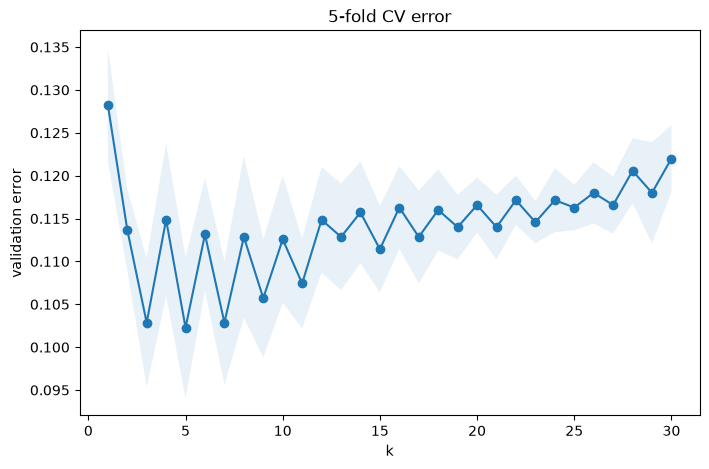

In [19]:
best_k = score_df.loc[score_df['accuracy'].idxmax(), 'k']
print('лучший k:', best_k)

ax = score_df.set_index('k')['error'].plot(marker='o', figsize=(8, 5))
ax.fill_between(score_df['k'], score_df['error'] - score_df['std'], score_df['error'] + score_df['std'], alpha=0.1)
ax.set(xlabel='k', ylabel='validation error', title='5-fold CV error');

Оптимальное значение K = 5 (accuracy 0.898 на кросс-валидации), но K = 3 и K = 7 почти такие же, разница меньше одного std. При маленьком K модель подстраивается под отдельные точки, а при большом граница слишком сглаживается, и предсказания смещаются к классу 0, потому что ушедших всего 14%. Четные K почти всегда хуже соседних нечетных: при четном K бывает ничья, и sklearn отдает ее классу 0.

### Упражнение 8: Работа с несбалансированными классами (Class Imbalance)
В наборе данных Orange Telecom мажоритарный класс представляют клиенты, которые не ушли (`churned = False`), а ушедшие — меньшинство. Объясните, почему метрика `accuracy` (точность) в данном контексте вводит в заблуждение. Измените код оценки для расчета матрицы ошибок (Confusion Matrix), Precision, Recall и F1-score с использованием `sklearn.metrics`.

In [20]:
from sklearn.metrics import confusion_matrix, classification_report
# Напишите код для расчета метрик

model = Pipeline([('scaler', MinMaxScaler()), ('knn', KNeighborsClassifier(n_neighbors=best_k))])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('accuracy KNN:', accuracy(y_test, y_pred))
# а если всегда отвечать "не ушел"
print('accuracy без модели:', accuracy(y_test, np.zeros(len(y_test))))

accuracy KNN: 0.8993333333333333
accuracy без модели: 0.8586666666666667


In [21]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1263   25]
 [ 126   86]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      1288
           1       0.77      0.41      0.53       212

    accuracy                           0.90      1500
   macro avg       0.84      0.69      0.74      1500
weighted avg       0.89      0.90      0.89      1500



Около 86% клиентов не уходят, поэтому "модель", которая всегда говорит "не ушел", уже получает accuracy 0.86 и не находит ни одного ушедшего. У KNN accuracy 0.90, вроде бы хорошо, но recall для ушедших всего 0.41: модель нашла 86 ушедших из 212, а 126 пропустила (левая нижняя клетка confusion matrix). Поэтому при несбалансированных классах смотрим метрики для класса 1: precision (сколько из предсказанных ушедших ушли на самом деле), recall (скольких ушедших нашли) и f1 (среднее гармоническое precision и recall).

### Упражнение 9: Влияние весов расстояния (`weights='distance'`) против равномерных весов
Сравните поведение модели KNN при `weights='uniform'` и `weights='distance'`. Напишите эксперимент на Python, оценивающий чувствительность модели к шуму (выбросам в пространстве признаков) для обоих типов весов. Какой вариант более уязвим к шуму и почему?

In [22]:
# Эксперимент с весами

from sklearn.datasets import make_circles

# для наглядности берем двумерные данные: два кольца, внутреннее и внешнее
X_c, y_c = make_circles(n_samples=3000, noise=0.2, factor=0.5, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.3, random_state=42)

# выбросы: часть точек train сдвигаем в случайную сторону, метки не меняем, test не трогаем
rng = np.random.default_rng(42)
for share in [0, 0.1, 0.2, 0.3]:
    X_noisy = X_train_c.copy()
    idx = rng.choice(len(X_noisy), int(share * len(X_noisy)), replace=False)
    X_noisy[idx] += rng.normal(0, 0.6, size=(len(idx), 2))
    for w in ['uniform', 'distance']:
        knn = KNeighborsClassifier(n_neighbors=11, weights=w).fit(X_noisy, y_train_c)
        print('выбросов', share, w, round(knn.score(X_test_c, y_test_c), 4))

выбросов 0 uniform 0.8744
выбросов 0 distance 0.8689
выбросов 0.1 uniform 0.8756
выбросов 0.1 distance 0.8667
выбросов 0.2 uniform 0.8622
выбросов 0.2 distance 0.8556
выбросов 0.3 uniform 0.8544
выбросов 0.3 distance 0.8411


Более уязвим вариант `weights='distance'`. При `uniform` у каждого из 11 соседей один голос, поэтому один выброс меняет голосование не больше, чем на 1/11. При `distance` вес соседа равен 1/d, и выброс, который случайно оказался совсем рядом с точкой, перевешивает остальных соседей и может один поменять ответ. В эксперименте `distance` при любой доле выбросов хуже, и разница растет: без выбросов 0.869 против 0.874 у `uniform`, а при 30% выбросов 0.841 против 0.854.

### Упражнение 10: Проклятие размерности (Curse of Dimensionality)
Алгоритм KNN основан на измерении расстояний в многомерных пространствах. С ростом числа признаков объем пространства растет экспоненциально, и точки становятся равноудаленными. Напишите небольшой кейс или эксперимент на Python, показывающий, как искусственное увеличение размерности (добавление колонок случайного шума к данным churn) ухудшает производительность классификатора KNN.

In [23]:
# Эксперимент с проклятием размерности

# добавляем к churn колонки случайного шума из [0, 1], это тот же масштаб, что у признаков после MinMax
model = Pipeline([('scaler', MinMaxScaler()), ('knn', KNeighborsClassifier(n_neighbors=best_k))])
rng = np.random.default_rng(42)

score_list = list()
for n_noise in [0, 3, 10, 30, 100, 300]:
    X_big = np.hstack([X_train.values, rng.random((len(X_train), n_noise))])
    acc = cross_val_score(model, X_big, y_train, cv=skf, scoring='accuracy').mean()
    f1 = cross_val_score(model, X_big, y_train, cv=skf, scoring='f1').mean()
    score_list.append((n_noise, acc, f1))

dim_df = pd.DataFrame(score_list, columns=['noise_columns', 'accuracy', 'f1'])
dim_df

# KNN считает все признаки одинаково важными, поэтому шумовые колонки добавляют к каждому расстоянию случайную часть,
# и 17 полезных признаков в ней теряются. Соседи становятся почти случайными: accuracy падает до 0.85,
# это уже хуже, чем всегда отвечать "не ушел" (0.86), а f1 для ушедших почти до нуля.

,noise_columns,accuracy,f1
0,0,0.897714,0.486085
1,3,0.877714,0.337781
2,10,0.859714,0.174208
3,30,0.857429,0.151883
4,100,0.856571,0.045582
5,300,0.847429,0.043117


### Упражнение 11: KNN для регрессии против классификации
Хотя в ноутбуке мы использовали `KNeighborsClassifier` для задачи бинарной классификации, KNN также применим для регрессии (`KNeighborsRegressor`). Напишите скрипт, применяющий `KNeighborsRegressor` для предсказания непрерывной переменной (например, `total_day_charges` на основе минут и звонков). Сравните функцию потерь (MSE — Mean Squared Error) для различных значений K.

In [24]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
# Ваш код регрессии

# сначала посмотрим, как связаны charge и минуты
(data['total_day_charge'] / data['total_day_minutes']).describe()

count    4998.000000
mean        0.170003
std         0.000027
min         0.169231
25%         0.169989
50%         0.170004
75%         0.170017
max         0.170513
dtype: float64

In [25]:
# отношение всегда 0.17, значит charge = 0.17 * minutes, и задача почти тривиальная
features = ['total_day_minutes', 'total_day_calls']
target = 'total_day_charge'

score_list = list()
for k in [1, 2, 4, 8, 15, 30, 60, 120]:
    reg = Pipeline([('scaler', MinMaxScaler()), ('knn', KNeighborsRegressor(n_neighbors=k))])
    reg.fit(X_train[features], X_train[target])
    mse_train = mean_squared_error(X_train[target], reg.predict(X_train[features]))
    mse_test = mean_squared_error(X_test[target], reg.predict(X_test[features]))
    score_list.append((k, mse_train, mse_test))

mse_df = pd.DataFrame(score_list, columns=['k', 'mse_train', 'mse_test'])
mse_df

# KNeighborsRegressor предсказывает среднее target у K ближайших соседей.
# Лучший MSE на test при k = 2. При k = 1 на train ошибка почти 0, это опять запоминание,
# а при большом K соседи берутся из слишком широкого диапазона минут, и ошибка растет.
# total_day_calls на charge не влияет, его взяли только потому, что так в условии.
# Для такой линейной зависимости лучше подошла бы линейная регрессия.

,k,mse_train,mse_test
0,1,0.000000,0.116324
1,2,0.034560,0.093015
2,4,0.068146,0.136056
3,8,0.140995,0.252700
4,15,0.216895,0.357332
5,30,0.386234,0.536708
6,60,0.729830,0.886795
7,120,1.453702,1.589324


### Упражнение 12: Пайплайны машинного обучения с `Pipeline` и `GridSearchCV`
Постройте полный пайплайн в Scikit-learn, включающий: (1) `MinMaxScaler`, (2) опционально селектор признаков (`SelectKBest`) и (3) `KNeighborsClassifier`. Используйте `GridSearchCV` для одновременного поиска оптимальных гиперпараметров: количества соседей K in {3, 5, 7, 9, 11}, типа весов (`uniform`, `distance`) и метрики расстояния (p=1 или p=2). Выведите лучший набор гиперпараметров и оценку на тестовой выборке.

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest

# Настройка Pipeline и GridSearchCV

pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('select', SelectKBest()),  # по умолчанию f_classif, он оценивает, насколько признак отличается у ушедших и оставшихся
    ('knn', KNeighborsClassifier()),
])

# имена параметров пишутся как <название шага>__<параметр>
params = {
    'select__k': [4, 8, 12, 'all'],  # 'all' значит без отбора признаков
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2],
}

# scoring='f1', а не accuracy, потому что нам важно находить ушедших (упражнение 8)
grid = GridSearchCV(pipe, params, cv=skf, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(grid.best_params_)
print('лучший f1 на кросс-валидации:', round(grid.best_score_, 4))


{'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'uniform', 'select__k': 12}
лучший f1 на кросс-валидации: 0.6131


In [27]:
# test используем один раз, в самом конце. grid уже обучил лучшую модель на всем train (refit=True по умолчанию)
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))

selected = grid.best_estimator_.named_steps['select'].get_support()
print('выбранные признаки:', list(X_train.columns[selected]))

# По сравнению с упражнением 8 recall для ушедших вырос с 0.41 до 0.52, а f1 с 0.53 до 0.64.

              precision    recall  f1-score   support

           0       0.93      0.98      0.95      1288
           1       0.83      0.52      0.64       212

    accuracy                           0.92      1500
   macro avg       0.88      0.75      0.80      1500
weighted avg       0.91      0.92      0.91      1500

выбранные признаки: ['intl_plan', 'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes', 'total_day_charge', 'total_eve_minutes', 'total_eve_charge', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'number_customer_service_calls']
